**Block 1: Libraries Installation & Imports**



In [6]:
# Install required libraries for document creation and conversion
!pip install python-docx scipy statsmodels seaborn matplotlib pandas numpy -q
!apt-get update -qq && apt-get install -y libreoffice -qq

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from google.colab import files

# Set plot styling
sns.set_theme(style="whitegrid", palette="muted")
print("Environment configured successfully.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Environment configured successfully.


**Block 2: Dataset Preparation & Feature Engineering**

In [7]:
# Load dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Data Cleaning and Imputation
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Feature Engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

print(f"Dataset Loaded Successfully: {df.shape[0]} rows, {df.shape[1]} columns.")

Dataset Loaded Successfully: 891 rows, 14 columns.


**Block 3: Hypothesis 1 — Two-Sample Welch's t-Test (Continuous vs Binary)Hypothesis:**

$H_0$: There is no difference in the mean fare paid by survivors and non-survivors ($\mu_{\text{survived}} = \mu_{\text{non-survived}}$).

$H_1$: Survivors paid a significantly higher mean fare than non-survivors ($\mu_{\text{survived}} > \mu_{\text{non-survived}}$).

--- HYPOTHESIS 1 RESULTS ---
Mean Fare (Survived): $48.40 (SD: 66.60)
Mean Fare (Died): $22.12 (SD: 31.39)
t-statistic: 6.8391, p-value: 1.3497e-11


/tmp/ipykernel_2804/4218687718.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=df, palette='Set2', showfliers=False)


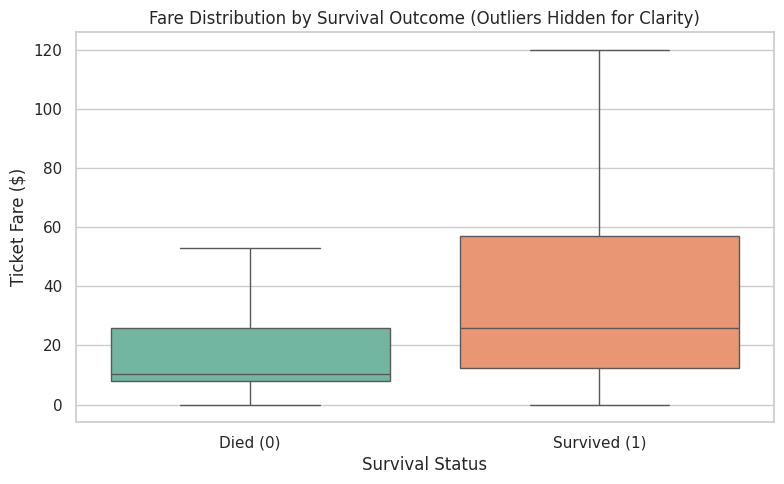

In [8]:
# Separate fare data
fare_survived = df[df['Survived'] == 1]['Fare']
fare_died = df[df['Survived'] == 0]['Fare']

# Execute Welch's t-test (equal_var=False)
t_stat, p_val_two = stats.ttest_ind(fare_survived, fare_died, equal_var=False)
p_val_one = p_val_two / 2 if t_stat > 0 else 1 - (p_val_two / 2)

# Calculate Descriptive Stats & Confidence Interval
mean_surv, std_surv = fare_survived.mean(), fare_survived.std()
mean_died, std_died = fare_died.mean(), fare_died.std()

print("--- HYPOTHESIS 1 RESULTS ---")
print(f"Mean Fare (Survived): ${mean_surv:.2f} (SD: {std_surv:.2f})")
print(f"Mean Fare (Died): ${mean_died:.2f} (SD: {std_died:.2f})")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val_one:.4e}")

# Plot Visualization
plt.figure(figsize=(8, 5))
sns.boxplot(x='Survived', y='Fare', data=df, palette='Set2', showfliers=False)
plt.xticks([0, 1], ['Died (0)', 'Survived (1)'])
plt.title('Fare Distribution by Survival Outcome (Outliers Hidden for Clarity)')
plt.ylabel('Ticket Fare ($)')
plt.xlabel('Survival Status')
plt.tight_layout()
plt.savefig('h1_ttest_plot.png', dpi=300)
plt.show()

**Block 4: Hypothesis 2 — Chi-Square Test of Independence (Categorical vs Categorical)Hypothesis:**

$H_0$: Passenger Class (Pclass) and Survival (Survived) are independent.

$H_1$: Passenger Class (Pclass) and Survival (Survived) are dependent.

--- HYPOTHESIS 2 RESULTS ---
Chi2 Statistic: 102.8890, Degrees of Freedom: 2
p-value: 4.5493e-23
Cramér's V Effect Size: 0.3398


<Figure size 800x500 with 0 Axes>

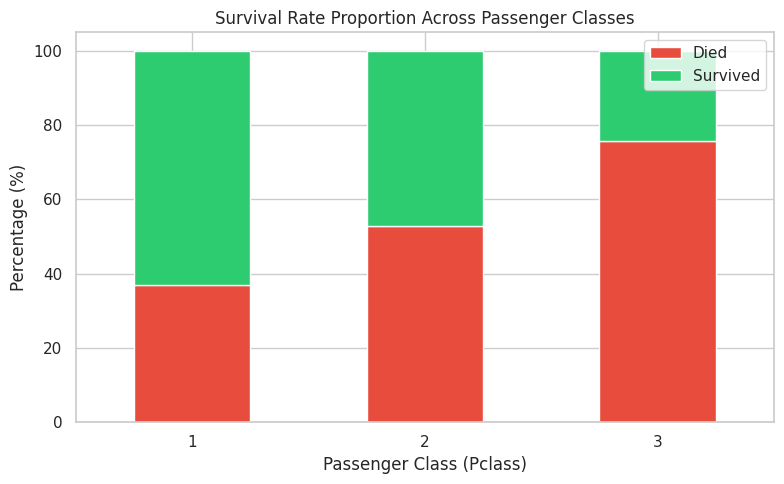

In [9]:
# Create Contingency Table
contingency_table = pd.crosstab(df['Pclass'], df['Survived'])

# Execute Chi-Square Test
chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)

# Calculate Cramér's V (Effect Size)
n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2_stat / (n * (min(contingency_table.shape) - 1)))

print("--- HYPOTHESIS 2 RESULTS ---")
print(f"Chi2 Statistic: {chi2_stat:.4f}, Degrees of Freedom: {dof}")
print(f"p-value: {p_val_chi2:.4e}")
print(f"Cramér's V Effect Size: {cramers_v:.4f}")

# Plot Visualization
plt.figure(figsize=(8, 5))
prop_df = pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100
prop_df.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'], figsize=(8, 5))
plt.title('Survival Rate Proportion Across Passenger Classes')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Percentage (%)')
plt.legend(['Died', 'Survived'], loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('h2_chisq_plot.png', dpi=300)
plt.show()

**Block 5: Hypothesis 3 — One-Way ANOVA & Post-Hoc Tukey HSD (Continuous across >2 Groups)Hypothesis:**

$H_0$: Mean passenger age is identical across all embarkation ports ($\mu_C = \mu_Q = \mu_S$).

$H_1$: At least one embarkation port has a significantly different mean passenger age.

--- HYPOTHESIS 3 RESULTS ---
F-statistic: 3.3570, p-value: 3.5283e-02


/tmp/ipykernel_2804/3829221589.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Embarked', y='Age', data=df, palette='Pastel1', inner='quartile')


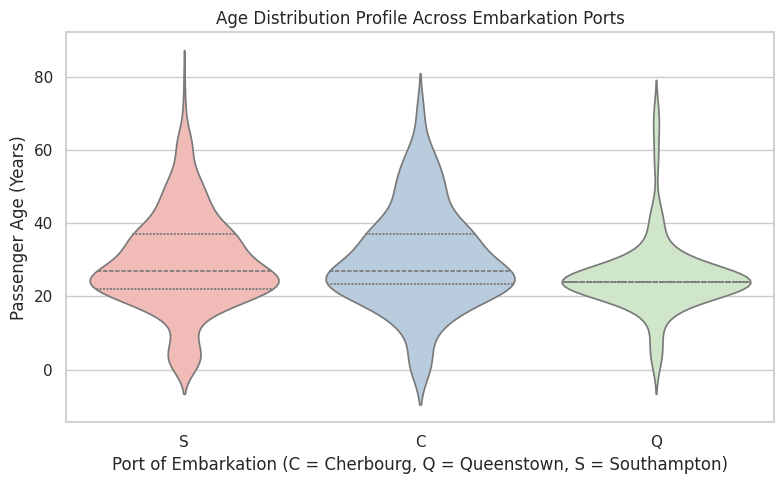

In [10]:
# Execute One-Way ANOVA
f_stat, p_val_anova = stats.f_oneway(
    df[df['Embarked'] == 'C']['Age'],
    df[df['Embarked'] == 'Q']['Age'],
    df[df['Embarked'] == 'S']['Age']
)

print("--- HYPOTHESIS 3 RESULTS ---")
print(f"F-statistic: {f_stat:.4f}, p-value: {p_val_anova:.4e}")

# Plot Visualization
plt.figure(figsize=(8, 5))
sns.violinplot(x='Embarked', y='Age', data=df, palette='Pastel1', inner='quartile')
plt.title('Age Distribution Profile Across Embarkation Ports')
plt.xlabel('Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)')
plt.ylabel('Passenger Age (Years)')
plt.tight_layout()
plt.savefig('h3_anova_plot.png', dpi=300)
plt.show()